# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification

**Top-3 models carried over from Lab Activity 1** (ranked by test accuracy, ties broken by macro-F1):

| Rank | Model | Accuracy | Macro-F1 | AUC |
|---|---|---|---|---|
| 1 | **ResNet50** | 78.12 % | 76.40 | 90.98 |
| 2 | **AlexNet** | 75.00 % | 74.15 | 90.66 |
| 3 | **ResNet101** | 75.00 % | 70.78 | 92.02 |

**Experiment grid:** 3 models x 6 conditions (No Filter, Average, Gaussian, Median, Sharpening, Sobel) = **18 training runs**.

**Dataset:** the same instructor-approved 4-class ISIC subset used in Lab 1 — `melanoma`, `nevus`,
`pigmented benign keratosis`, `basal cell carcinoma` — with the **identical 80/20 split (seed 42)**,
identical preprocessing and identical evaluation procedure, so results stay comparable across Lab 1 and Lab 2.

---

### T4 optimisations used here
| Technique | Effect |
|---|---|
| JPEGs decoded + resized to 224 **once**, cached as `uint8` | removes the CPU decode bottleneck (Colab has only 2 vCPUs) |
| Filters applied **once per variant**, not per epoch | 10x less CPU work than filtering inside the DataLoader |
| Whole dataset held **on the GPU** (~320 MB) | zero host-to-device transfer, no DataLoader workers needed |
| Mixed precision (AMP, fp16) + `channels_last` | ~2x faster on T4 tensor cores |
| Vectorised **GPU-side augmentation** (flip / rotate / scale / jitter) | augmentation costs almost nothing |
| `cudnn.benchmark = True`, batch 64 | best kernels auto-selected |
| Results checkpointed to JSON after every run | a Colab disconnect never loses finished runs |

Expected total runtime: **~60-75 min** on a T4.


## 0. Environment setup

In [1]:
!pip install -q tabulate
import subprocess, torch
print(subprocess.run(["nvidia-smi","--query-gpu=name,memory.total","--format=csv,noheader"],
                     capture_output=True, text=True).stdout)
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

Tesla T4, 15360 MiB

PyTorch: 2.11.0+cu128 | CUDA: True


In [2]:
import os, gc, json, math, time, random, copy, warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
from concurrent.futures import ThreadPoolExecutor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, balanced_accuracy_score, confusion_matrix,
                             classification_report)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ---------------- Reproducibility ----------------
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

# ---------------- Config ----------------
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE     = 224
NUM_CLASSES  = 4
BATCH_SIZE   = 64
EPOCHS       = 15
WARMUP_EPOCHS= 1
PATIENCE     = 5
LR_BACKBONE  = 1e-4
LR_HEAD      = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
DROPOUT      = 0.3
USE_TTA      = True          # flip test-time augmentation (applied identically to every run)

MODEL_NAMES  = ["ResNet50", "AlexNet", "ResNet101"]   # <- top-3 from Lab 1 (swap here if needed)
FILTERS      = ["No Filter", "Average", "Gaussian", "Median", "Sharpening", "Sobel"]

RESULT_DIR   = "/content/results"
os.makedirs(RESULT_DIR, exist_ok=True)
RESULT_JSON  = f"{RESULT_DIR}/results.json"

# T4 speed switches
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("Device:", DEVICE)

Device: cuda


---
## 1. Dataset preparation

Same source, same 4 classes and same split generator (`manual_seed(42)`) as Lab Activity 1.

In [3]:
import kagglehub
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")

dataset_root = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")
train_dir = os.path.join(dataset_root, "Train")
test_dir  = os.path.join(dataset_root, "Test")

SELECTED_CLASSES = sorted([
    "melanoma",
    "nevus",
    "pigmented benign keratosis",
    "basal cell carcinoma",
])
CLASS_NAMES = SELECTED_CLASSES
SHORT_NAMES = ["BCC", "MEL", "NV", "PBK"]   # basal cell carcinoma, melanoma, nevus, pigmented benign keratosis

print("Classes:", CLASS_NAMES)

100%|██████████| 786M/786M [00:40<00:00, 20.1MB/s]

Extracting files...


Classes: ['basal cell carcinoma', 'melanoma', 'nevus', 'pigmented benign keratosis']


In [4]:
# Build the file list exactly the way torchvision.ImageFolder would (sorted classes, sorted files)
def build_file_list(root):
    files, labels = [], []
    for ci, cname in enumerate(SELECTED_CLASSES):
        cdir = os.path.join(root, cname)
        for fn in sorted(os.listdir(cdir)):
            fp = os.path.join(cdir, fn)
            if os.path.isfile(fp):
                files.append(fp); labels.append(ci)
    return files, np.array(labels, dtype=np.int64)

trainval_files, trainval_labels = build_file_list(train_dir)
test_files,     test_labels     = build_file_list(test_dir)

print(f"Train+Val images: {len(trainval_files)}")
print(f"Test images     : {len(test_files)}")

# ---- identical split to Lab 1: randperm with generator seeded at 42, 80/20 ----
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(trainval_files), generator=g).tolist()
n_train = int(0.8 * len(perm))
train_idx = np.array(perm[:n_train]); val_idx = np.array(perm[n_train:])

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_files)}")

Train+Val images: 1633
Test images     : 64
Train: 1306 | Val: 327 | Test: 64


### 1.1 Class distribution

,Class,Train,Val,Test,Total
0,basal cell carcinoma,293,83,16,392
1,melanoma,351,87,16,454
2,nevus,288,69,16,373
3,pigmented benign keratosis,374,88,16,478


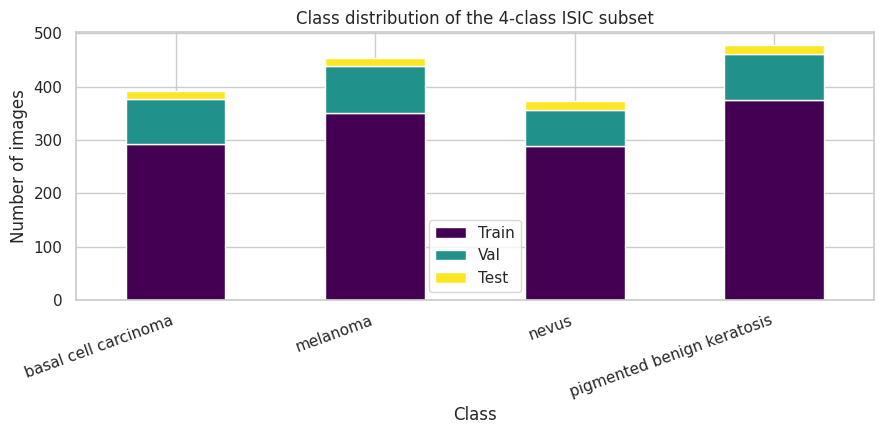

In [5]:
rows = []
for ci, c in enumerate(SELECTED_CLASSES):
    rows.append({"Class": c,
                 "Train": int((trainval_labels[train_idx] == ci).sum()),
                 "Val":   int((trainval_labels[val_idx]   == ci).sum()),
                 "Test":  int((test_labels == ci).sum())})
dist_df = pd.DataFrame(rows)
dist_df["Total"] = dist_df[["Train","Val","Test"]].sum(axis=1)
display(dist_df)

ax = dist_df.set_index("Class")[["Train","Val","Test"]].plot(
        kind="bar", stacked=True, figsize=(9,4.5), colormap="viridis")
ax.set_title("Class distribution of the 4-class ISIC subset")
ax.set_ylabel("Number of images"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/class_distribution.png", dpi=150); plt.show()

### 1.2 Decode + resize **once** and cache in RAM

Every image is JPEG-decoded and resized to 224x224 a single time for the whole notebook.
All 18 runs then reuse this `uint8` cache, which is what makes the experiment grid fast.

In [6]:
def load_and_resize(fp):
    img = cv2.imread(fp, cv2.IMREAD_COLOR)          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)      # RGB
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def load_all(files):
    with ThreadPoolExecutor(max_workers=8) as ex:
        imgs = list(ex.map(load_and_resize, files))
    return np.stack(imgs).astype(np.uint8)          # [N, H, W, 3]

t0 = time.time()
RAW_TRAINVAL = load_all(trainval_files)
RAW_TEST     = load_all(test_files)
print(f"Decoded in {time.time()-t0:.1f}s")
print("Train+Val cache:", RAW_TRAINVAL.shape, f"{RAW_TRAINVAL.nbytes/1e6:.0f} MB")
print("Test cache     :", RAW_TEST.shape,     f"{RAW_TEST.nbytes/1e6:.0f} MB")

Decoded in 18.6s
Train+Val cache: (1633, 224, 224, 3) 246 MB
Test cache     : (64, 224, 224, 3) 10 MB


---
## 2. Image filtering

All five spatial-domain filters operate on the **224x224 uint8 RGB image**, i.e. at exactly the
resolution the network sees, and are applied identically to **train, validation and test** images.
Only the filter changes between experiments — split, augmentation, optimiser, schedule and
evaluation are held constant.

| Filter | Implementation | Kernel |
|---|---|---|
| Average / Mean | `cv2.blur` | 3x3 box |
| Gaussian | `cv2.GaussianBlur` | 5x5, sigma = 1.0 |
| Median | `cv2.medianBlur` | 3x3 |
| Sharpening | `cv2.filter2D` | `[[0,-1,0],[-1,5,-1],[0,-1,0]]` |
| Sobel | gradient magnitude on grayscale, min-max scaled to 0-255, replicated to 3 channels | 3x3 Sobel x & y |

The Sobel output is replicated across the three channels so the tensor shape and the ImageNet
normalisation stay unchanged — the pretrained stem still receives a valid 3-channel input.

In [7]:
SHARPEN_KERNEL = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)

def f_none(img):      return img

def f_average(img):   return cv2.blur(img, (3, 3))

def f_gaussian(img):  return cv2.GaussianBlur(img, (5, 5), sigmaX=1.0)

def f_median(img):    return cv2.medianBlur(img, 3)

def f_sharpen(img):   return cv2.filter2D(img, -1, SHARPEN_KERNEL)   # cv2 saturates to uint8

def f_sobel(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx, gy)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return np.repeat(mag[:, :, None], 3, axis=2)

FILTER_FNS = {
    "No Filter":  f_none,
    "Average":    f_average,
    "Gaussian":   f_gaussian,
    "Median":     f_median,
    "Sharpening": f_sharpen,
    "Sobel":      f_sobel,
}

def apply_filter(arr, fname):
    """Apply a filter to a cached uint8 array [N,H,W,3]. Returns a new uint8 array."""
    fn = FILTER_FNS[fname]
    if fname == "No Filter":
        return arr
    with ThreadPoolExecutor(max_workers=8) as ex:
        out = list(ex.map(fn, arr))
    return np.stack(out).astype(np.uint8)

print("Filters ready:", list(FILTER_FNS))

Filters ready: ['No Filter', 'Average', 'Gaussian', 'Median', 'Sharpening', 'Sobel']


### 2.1 Original vs filtered examples

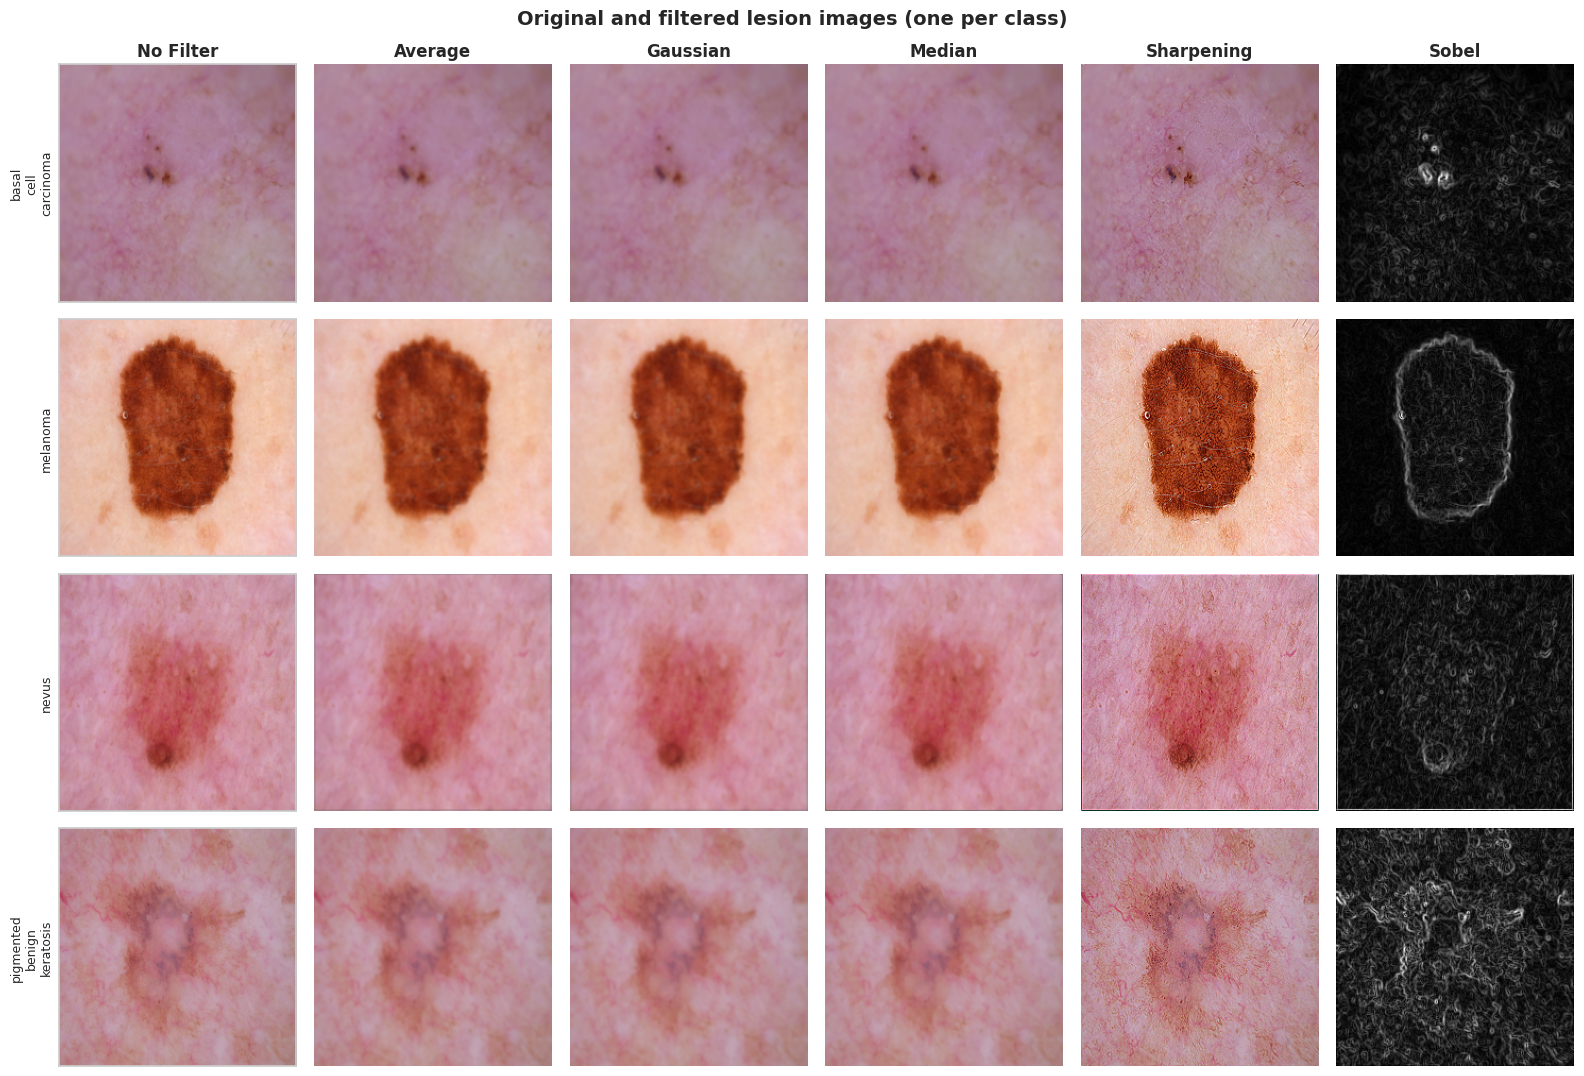

In [8]:
set_seed()
sample_ids = [int(np.where(trainval_labels == c)[0][5]) for c in range(NUM_CLASSES)]

fig, axes = plt.subplots(NUM_CLASSES, len(FILTERS), figsize=(16, 11))
for r, sid in enumerate(sample_ids):
    for c, fname in enumerate(FILTERS):
        axes[r, c].imshow(FILTER_FNS[fname](RAW_TRAINVAL[sid]))
        axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(fname, fontsize=12, fontweight="bold")
        if c == 0: axes[r, c].set_ylabel(SHORT_NAMES[r])
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    axes[r, 0].set_ylabel(SELECTED_CLASSES[r].replace(" ", "\n"), fontsize=9)
plt.suptitle("Original and filtered lesion images (one per class)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/filter_examples.png", dpi=150); plt.show()

---
## 3. GPU data pipeline

The filtered `uint8` dataset (~320 MB) is uploaded to the T4 once per filter variant. Batching,
normalisation and augmentation then happen entirely on-device, so no DataLoader workers and no
per-batch host-to-device copies are needed.

In [9]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1,3,1,1)

def to_gpu_uint8(arr):
    """[N,H,W,3] uint8 numpy -> [N,3,H,W] uint8 cuda tensor."""
    t = torch.from_numpy(np.ascontiguousarray(arr)).to(DEVICE, non_blocking=True)
    return t.permute(0, 3, 1, 2).contiguous()

def normalize(x_uint8):
    x = x_uint8.float().div_(255.0)
    return (x - IMAGENET_MEAN) / IMAGENET_STD

def gpu_augment(x):
    """Per-sample random flips, +-15 deg rotation, 0.9-1.1 scale, mild brightness/contrast jitter.
    x: float tensor [B,3,H,W], already normalised range-free (0-1 domain)."""
    B = x.size(0)
    # horizontal / vertical flips
    fh = torch.rand(B, device=x.device) < 0.5
    x = torch.where(fh.view(-1,1,1,1), x.flip(-1), x)
    fv = torch.rand(B, device=x.device) < 0.5
    x = torch.where(fv.view(-1,1,1,1), x.flip(-2), x)
    # rotation + isotropic scale via a batched affine grid
    ang = (torch.rand(B, device=x.device) * 2 - 1) * (15 * math.pi / 180)
    sc  = 1.0 + (torch.rand(B, device=x.device) * 2 - 1) * 0.10
    cos, sin = torch.cos(ang) / sc, torch.sin(ang) / sc
    theta = torch.zeros(B, 2, 3, device=x.device, dtype=x.dtype)
    theta[:,0,0] =  cos; theta[:,0,1] = -sin
    theta[:,1,0] =  sin; theta[:,1,1] =  cos
    grid = F.affine_grid(theta, list(x.shape), align_corners=False)
    x = F.grid_sample(x, grid, mode="bilinear", padding_mode="reflection", align_corners=False)
    # brightness / contrast jitter
    b = 1.0 + (torch.rand(B,1,1,1, device=x.device) * 2 - 1) * 0.15
    c = 1.0 + (torch.rand(B,1,1,1, device=x.device) * 2 - 1) * 0.15
    mean = x.mean(dim=(1,2,3), keepdim=True)
    x = ((x - mean) * c + mean) * b
    return x.clamp_(0.0, 1.0)

def make_batch(cache_u8, idx, train=False):
    xb = cache_u8[idx].float().div_(255.0)
    if train:
        xb = gpu_augment(xb)
    xb = (xb - IMAGENET_MEAN) / IMAGENET_STD
    return xb.contiguous(memory_format=torch.channels_last)

print("GPU pipeline ready.")

GPU pipeline ready.


---
## 4. Model loading

The three Lab-1 winners, each with the **same classification head**: `Dropout(0.3) -> Linear(feat, 4)`
followed by softmax (cross-entropy). Lab 1 already showed this fine-tuned linear head beats every
classical head on ResNet50 features (78.1 % vs 76.6 % logistic regression, 75.0 % SVM/XGBoost,
73.4 % random forest), so it is the one head used everywhere here.

In [10]:
def build_model(name):
    if name == "ResNet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(m.fc.in_features, NUM_CLASSES))
        head = m.fc
    elif name == "ResNet101":
        m = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        m.fc = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(m.fc.in_features, NUM_CLASSES))
        head = m.fc
    elif name == "AlexNet":
        m = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        in_f = m.classifier[6].in_features
        m.classifier[6] = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(in_f, NUM_CLASSES))
        head = m.classifier[6]
    else:
        raise ValueError(name)
    m = m.to(DEVICE, memory_format=torch.channels_last)
    return m, head

def param_groups(model, head):
    head_ids = {id(p) for p in head.parameters()}
    backbone = [p for p in model.parameters() if id(p) not in head_ids and p.requires_grad]
    headp    = [p for p in model.parameters() if id(p) in head_ids and p.requires_grad]
    return [{"params": backbone, "lr": LR_BACKBONE},
            {"params": headp,    "lr": LR_HEAD}]

for n in MODEL_NAMES:
    m, _ = build_model(n)
    print(f"{n:<11} {sum(p.numel() for p in m.parameters())/1e6:6.2f} M params")
    del m; gc.collect(); torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


ResNet50     23.52 M params
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 182MB/s]


AlexNet      57.02 M params
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 94.2MB/s]


ResNet101    42.51 M params


---
## 5. Training

Best practices applied uniformly to all 18 runs:

* **AdamW** with discriminative learning rates (backbone `1e-4`, head `1e-3`) and weight decay `1e-4`
* **Cosine-annealed** schedule with a 1-epoch linear warm-up
* **Class-weighted** cross-entropy with **label smoothing 0.05** (handles the mild class imbalance)
* **Mixed precision** (`torch.amp`) + `channels_last`
* Model selection and early stopping on **validation macro-F1** (not raw accuracy — better for imbalance),
  `patience = 5`, best weights restored

In [11]:
def evaluate(model, cache_u8, labels_np, tta=False, return_probs=True):
    model.eval()
    N = cache_u8.size(0)
    probs = torch.zeros(N, NUM_CLASSES, device=DEVICE)
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=DEVICE.type=="cuda"):
        for s in range(0, N, BATCH_SIZE):
            idx = torch.arange(s, min(s+BATCH_SIZE, N), device=DEVICE)
            xb  = make_batch(cache_u8, idx, train=False)
            views = [xb, xb.flip(-1), xb.flip(-2), xb.flip(-1).flip(-2)] if tta else [xb]
            p = torch.zeros(xb.size(0), NUM_CLASSES, device=DEVICE)
            for v in views:
                p += torch.softmax(model(v).float(), dim=1)
            probs[s:s+xb.size(0)] = p / len(views)
    probs = probs.cpu().numpy()
    probs = probs / np.clip(probs.sum(axis=1, keepdims=True), 1e-12, None)  # sklearn AUC needs rows summing to 1
    preds = probs.argmax(1)
    return (preds, probs) if return_probs else preds


def compute_metrics(y_true, y_pred, y_prob):
    f = float   # keep everything JSON-serialisable (sklearn returns np.float64)
    m = {
        "accuracy":           f(accuracy_score(y_true, y_pred) * 100),
        "balanced_accuracy":  f(balanced_accuracy_score(y_true, y_pred) * 100),
        "precision_macro":    f(precision_score(y_true, y_pred, average="macro", zero_division=0) * 100),
        "recall_macro":       f(recall_score(y_true, y_pred, average="macro", zero_division=0) * 100),
        "f1_macro":           f(f1_score(y_true, y_pred, average="macro", zero_division=0) * 100),
        "precision_weighted": f(precision_score(y_true, y_pred, average="weighted", zero_division=0) * 100),
        "recall_weighted":    f(recall_score(y_true, y_pred, average="weighted", zero_division=0) * 100),
        "f1_weighted":        f(f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100),
    }
    try:
        m["auc"] = f(roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro") * 100)
    except Exception:
        m["auc"] = float("nan")
    return m


def train_one(model, head, tr_cache, tr_labels, va_cache, va_labels, class_weights, tag=""):
    opt = torch.optim.AdamW(param_groups(model, head), weight_decay=WEIGHT_DECAY)
    crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)
    scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")

    N = tr_cache.size(0)
    steps_per_epoch = math.ceil(N / BATCH_SIZE)
    total_steps  = steps_per_epoch * EPOCHS
    warmup_steps = steps_per_epoch * WARMUP_EPOCHS

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * min(prog, 1.0)))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

    tr_labels_t = torch.from_numpy(tr_labels).to(DEVICE)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_f1, best_wts, stale = -1.0, copy.deepcopy(model.state_dict()), 0

    for ep in range(EPOCHS):
        t0 = time.time(); model.train()
        perm = torch.randperm(N, device=DEVICE)
        run_loss, correct = 0.0, 0
        for s in range(0, N, BATCH_SIZE):
            idx = perm[s:s+BATCH_SIZE]
            xb  = make_batch(tr_cache, idx, train=True)
            yb  = tr_labels_t[idx]
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16, enabled=DEVICE.type=="cuda"):
                out  = model(xb)
                loss = crit(out, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(opt); scaler.update(); sched.step()
            run_loss += loss.item() * yb.size(0)
            correct  += (out.argmax(1) == yb).sum().item()

        # ---- validation (no TTA during model selection, keeps it fast) ----
        model.eval(); vloss, vcorrect = 0.0, 0
        vpreds = np.zeros(va_cache.size(0), dtype=np.int64)
        va_labels_t = torch.from_numpy(va_labels).to(DEVICE)
        with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16, enabled=DEVICE.type=="cuda"):
            for s in range(0, va_cache.size(0), BATCH_SIZE):
                idx = torch.arange(s, min(s+BATCH_SIZE, va_cache.size(0)), device=DEVICE)
                xb  = make_batch(va_cache, idx, train=False)
                yb  = va_labels_t[idx]
                out = model(xb)
                vloss    += crit(out, yb).item() * yb.size(0)
                pred      = out.argmax(1)
                vcorrect += (pred == yb).sum().item()
                vpreds[s:s+yb.size(0)] = pred.cpu().numpy()

        tr_loss = run_loss / N; tr_acc = correct / N
        va_loss = vloss / va_cache.size(0); va_acc = vcorrect / va_cache.size(0)
        va_f1   = float(f1_score(va_labels, vpreds, average="macro", zero_division=0))

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc * 100)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc * 100)
        history["val_f1"].append(float(va_f1) * 100)

        flag = ""
        if va_f1 > best_f1:
            best_f1 = va_f1; best_wts = copy.deepcopy(model.state_dict()); stale = 0; flag = "  *best"
        else:
            stale += 1
        print(f"  [{tag}] ep {ep+1:2d}/{EPOCHS} | loss {tr_loss:.4f} acc {tr_acc*100:5.2f}% "
              f"| val loss {va_loss:.4f} acc {va_acc*100:5.2f}% F1 {va_f1*100:5.2f}% "
              f"| {time.time()-t0:4.1f}s{flag}")
        if stale >= PATIENCE:
            print(f"  [{tag}] early stop at epoch {ep+1}")
            break

    model.load_state_dict(best_wts)
    return model, history, float(best_f1) * 100

print("Training utilities ready.")

Training utilities ready.


---
## 6. Experiment loop — 3 models x 6 filters

For each filter the dataset is regenerated once, pushed to the GPU, and all three models are trained
on it. Every finished run is appended to `results.json`, so re-running this cell after a Colab
disconnect resumes instead of starting over.

In [12]:
def load_results():
    if os.path.exists(RESULT_JSON):
        with open(RESULT_JSON) as f: return json.load(f)
    return {}

def save_results(res):
    with open(RESULT_JSON, "w") as f: json.dump(res, f, indent=2, default=float)

RESULTS = load_results()
print(f"Resuming with {len(RESULTS)} completed run(s).")

# class weights from the TRAIN split only
counts = np.bincount(trainval_labels[train_idx], minlength=NUM_CLASSES).astype(np.float32)
CLASS_WEIGHTS = torch.tensor(counts.sum() / (NUM_CLASSES * counts), device=DEVICE)
print("Class weights:", dict(zip(SHORT_NAMES, np.round(CLASS_WEIGHTS.cpu().numpy(), 3))))

y_val_np  = trainval_labels[val_idx]
y_test_np = test_labels

grand_t0 = time.time()

for fname in FILTERS:
    print("\n" + "=" * 78)
    print(f"FILTER: {fname}")
    print("=" * 78)

    pending = [m for m in MODEL_NAMES if f"{m}|{fname}" not in RESULTS]
    if not pending:
        print("  already complete, skipping."); continue

    # ---- build + upload this filter variant once ----
    t0 = time.time()
    tv_f = apply_filter(RAW_TRAINVAL, fname)
    te_f = apply_filter(RAW_TEST,     fname)
    tv_gpu = to_gpu_uint8(tv_f)
    te_gpu = to_gpu_uint8(te_f)
    tr_gpu = tv_gpu[torch.from_numpy(train_idx).to(DEVICE)].contiguous()
    va_gpu = tv_gpu[torch.from_numpy(val_idx).to(DEVICE)].contiguous()
    del tv_gpu, tv_f, te_f; gc.collect(); torch.cuda.empty_cache()
    print(f"  variant built + uploaded in {time.time()-t0:.1f}s "
          f"({sum(t.numel()*t.element_size() for t in (tr_gpu,va_gpu,te_gpu))/1e6:.0f} MB on GPU)")

    y_train_np = trainval_labels[train_idx]

    for mname in pending:
        set_seed(SEED)                       # identical init/augmentation stream for every run
        print(f"\n--- {mname} / {fname} ---")
        model, head = build_model(mname)
        model, hist, best_val_f1 = train_one(
            model, head, tr_gpu, y_train_np, va_gpu, y_val_np,
            CLASS_WEIGHTS, tag=f"{mname[:9]}/{fname[:6]}")

        # ---- evaluation ----
        va_pred, va_prob = evaluate(model, va_gpu, y_val_np, tta=False)
        val_metrics = compute_metrics(y_val_np, va_pred, va_prob)

        te_pred_p, te_prob_p = evaluate(model, te_gpu, y_test_np, tta=False)
        plain_metrics = compute_metrics(y_test_np, te_pred_p, te_prob_p)

        if USE_TTA:
            te_pred, te_prob = evaluate(model, te_gpu, y_test_np, tta=True)
        else:
            te_pred, te_prob = te_pred_p, te_prob_p
        test_metrics = compute_metrics(y_test_np, te_pred, te_prob)

        per_class = classification_report(y_test_np, te_pred, target_names=SELECTED_CLASSES,
                                          output_dict=True, zero_division=0)

        RESULTS[f"{mname}|{fname}"] = {
            "model": mname, "filter": fname,
            "test": test_metrics, "test_no_tta": plain_metrics, "val": val_metrics,
            "best_val_f1": best_val_f1, "history": hist,
            "y_true": y_test_np.tolist(), "y_pred": te_pred.tolist(),
            "per_class": per_class,
        }
        save_results(RESULTS)

        print(f"  -> TEST acc {test_metrics['accuracy']:.2f}% | macro-F1 "
              f"{test_metrics['f1_macro']:.2f}% | AUC {test_metrics['auc']:.2f}%")

        del model, head; gc.collect(); torch.cuda.empty_cache()

    del tr_gpu, va_gpu, te_gpu; gc.collect(); torch.cuda.empty_cache()

print(f"\nAll runs finished in {(time.time()-grand_t0)/60:.1f} min. "
      f"Total stored runs: {len(RESULTS)}")

Resuming with 0 completed run(s).
Class weights: {'BCC': np.float32(1.114), 'MEL': np.float32(0.93), 'NV': np.float32(1.134), 'PBK': np.float32(0.873)}

FILTER: No Filter
  variant built + uploaded in 0.3s (255 MB on GPU)

--- ResNet50 / No Filter ---
  [ResNet50/No Fil] ep  1/15 | loss 1.3310 acc 37.83% | val loss 1.1602 acc 59.63% F1 59.00% | 14.4s  *best
  [ResNet50/No Fil] ep  2/15 | loss 0.9605 acc 68.30% | val loss 0.8073 acc 74.31% F1 73.99% |  4.3s  *best
  [ResNet50/No Fil] ep  3/15 | loss 0.6505 acc 80.70% | val loss 0.7470 acc 75.54% F1 75.05% |  4.3s  *best
  [ResNet50/No Fil] ep  4/15 | loss 0.5454 acc 84.92% | val loss 0.7550 acc 74.92% F1 74.41% |  4.3s
  [ResNet50/No Fil] ep  5/15 | loss 0.4824 acc 88.28% | val loss 0.7203 acc 77.68% F1 77.02% |  4.4s  *best
  [ResNet50/No Fil] ep  6/15 | loss 0.4329 acc 91.04% | val loss 0.6456 acc 81.04% F1 80.31% |  4.4s  *best
  [ResNet50/No Fil] ep  7/15 | loss 0.3744 acc 93.80% | val loss 0.8647 acc 74.31% F1 74.32% |  4.4s
  [Res

---
## 7. Required results table

`Precision`, `Recall` and `F1-score` are **weighted** averages; `Macro-F1` is the unweighted macro
average, so the two F1 columns carry different information. `AUC` is one-vs-rest macro ROC-AUC.
The full CSV below also contains the macro variants, balanced accuracy and the no-TTA numbers in
case your instructor wants a different convention.

In [13]:
rows = []
for mname in MODEL_NAMES:
    for fname in FILTERS:
        key = f"{mname}|{fname}"
        if key not in RESULTS: continue
        t = RESULTS[key]["test"]
        rows.append({
            "Model": mname, "Filter": fname,
            "Accuracy":  round(t["accuracy"], 2),
            "Precision": round(t["precision_weighted"], 2),
            "Recall":    round(t["recall_weighted"], 2),
            "F1-score":  round(t["f1_weighted"], 2),
            "Macro-F1":  round(t["f1_macro"], 2),
            "AUC":       round(t["auc"], 2),
        })
main_df = pd.DataFrame(rows)
main_df.to_csv(f"{RESULT_DIR}/main_table.csv", index=False)
display(main_df.style.hide(axis="index").background_gradient(
    subset=["Accuracy", "Macro-F1", "AUC"], cmap="RdYlGn"))

print("\nMarkdown (paste straight into the report):\n")
print(main_df.to_markdown(index=False))

Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,AUC
ResNet50,No Filter,67.190000,78.010000,67.190000,60.470000,60.470000,92.940000
ResNet50,Average,68.750000,76.930000,68.750000,64.840000,64.840000,87.600000
ResNet50,Gaussian,67.190000,75.630000,67.190000,61.860000,61.860000,89.840000
ResNet50,Median,65.620000,75.080000,65.620000,58.910000,58.910000,89.420000
ResNet50,Sharpening,71.880000,79.960000,71.880000,66.170000,66.170000,94.760000
ResNet50,Sobel,60.940000,61.720000,60.940000,59.720000,59.720000,83.330000
AlexNet,No Filter,67.190000,73.200000,67.190000,64.850000,64.850000,90.200000
AlexNet,Average,64.060000,50.350000,64.060000,55.580000,55.580000,83.560000
AlexNet,Gaussian,65.620000,77.510000,65.620000,61.230000,61.230000,84.700000
AlexNet,Median,65.620000,77.110000,65.620000,60.660000,60.660000,88.570000



Markdown (paste straight into the report):

| Model     | Filter     |   Accuracy |   Precision |   Recall |   F1-score |   Macro-F1 |   AUC |
|:----------|:-----------|-----------:|------------:|---------:|-----------:|-----------:|------:|
| ResNet50  | No Filter  |      67.19 |       78.01 |    67.19 |      60.47 |      60.47 | 92.94 |
| ResNet50  | Average    |      68.75 |       76.93 |    68.75 |      64.84 |      64.84 | 87.6  |
| ResNet50  | Gaussian   |      67.19 |       75.63 |    67.19 |      61.86 |      61.86 | 89.84 |
| ResNet50  | Median     |      65.62 |       75.08 |    65.62 |      58.91 |      58.91 | 89.42 |
| ResNet50  | Sharpening |      71.88 |       79.96 |    71.88 |      66.17 |      66.17 | 94.76 |
| ResNet50  | Sobel      |      60.94 |       61.72 |    60.94 |      59.72 |      59.72 | 83.33 |
| AlexNet   | No Filter  |      67.19 |       73.2  |    67.19 |      64.85 |      64.85 | 90.2  |
| AlexNet   | Average    |      64.06 |       50.35 |    64.06 |

In [14]:
# --- full metric dump (macro + weighted + balanced acc + no-TTA) ---
full_rows = []
for key, r in RESULTS.items():
    row = {"Model": r["model"], "Filter": r["filter"], "BestValMacroF1": round(r["best_val_f1"], 2)}
    for split in ["test", "test_no_tta", "val"]:
        for k, v in r[split].items():
            row[f"{split}_{k}"] = round(v, 2)
    full_rows.append(row)
full_df = pd.DataFrame(full_rows)
order = {m: i for i, m in enumerate(MODEL_NAMES)}; forder = {f: i for i, f in enumerate(FILTERS)}
full_df = full_df.sort_values(by=["Model", "Filter"],
                              key=lambda s: s.map(order) if s.name == "Model" else s.map(forder))
full_df.to_csv(f"{RESULT_DIR}/full_metrics.csv", index=False)
display(full_df)

,Model,Filter,BestValMacroF1,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,...,test_no_tta_auc,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_weighted,val_recall_weighted,val_f1_weighted,val_auc
0,ResNet50,No Filter,80.40,67.19,67.19,78.01,67.19,60.47,78.01,67.19,...,93.00,80.73,80.21,82.12,80.21,80.40,82.56,80.73,80.84,95.42
3,ResNet50,Average,81.42,68.75,68.75,76.93,68.75,64.84,76.93,68.75,...,85.77,81.96,81.44,82.01,81.44,81.42,82.62,81.96,81.96,95.59
6,ResNet50,Gaussian,81.20,67.19,67.19,75.63,67.19,61.86,75.63,67.19,...,88.90,81.65,81.16,81.97,81.16,81.20,82.55,81.65,81.71,94.80
9,ResNet50,Median,76.31,65.62,65.62,75.08,65.62,58.91,75.08,65.62,...,89.52,77.37,77.32,78.56,77.32,76.31,79.23,77.37,76.58,94.21
12,ResNet50,Sharpening,82.33,71.88,71.88,79.96,71.88,66.17,79.96,71.88,...,94.89,82.87,82.45,83.25,82.45,82.33,83.76,82.87,82.76,94.52
15,ResNet50,Sobel,62.93,60.94,60.94,61.72,60.94,59.72,61.72,60.94,...,82.26,63.61,63.66,64.41,63.66,62.93,64.69,63.61,62.97,83.96
1,AlexNet,No Filter,82.97,67.19,67.19,73.20,67.19,64.85,73.20,67.19,...,90.14,83.49,83.00,83.02,83.00,82.97,83.62,83.49,83.51,95.23
4,AlexNet,Average,85.59,64.06,64.06,50.35,64.06,55.58,50.35,64.06,...,83.98,85.93,85.44,85.97,85.44,85.59,86.15,85.93,85.93,96.08
7,AlexNet,Gaussian,83.80,65.62,65.62,77.51,65.62,61.23,77.51,65.62,...,85.03,84.10,83.83,83.86,83.83,83.80,84.27,84.10,84.13,95.81
10,AlexNet,Median,85.65,65.62,65.62,77.11,65.62,60.66,77.11,65.62,...,88.64,85.93,85.54,86.13,85.54,85.65,86.26,85.93,85.90,96.03


---
## 8. Visualisation

### 8.1 Training / validation accuracy and loss curves

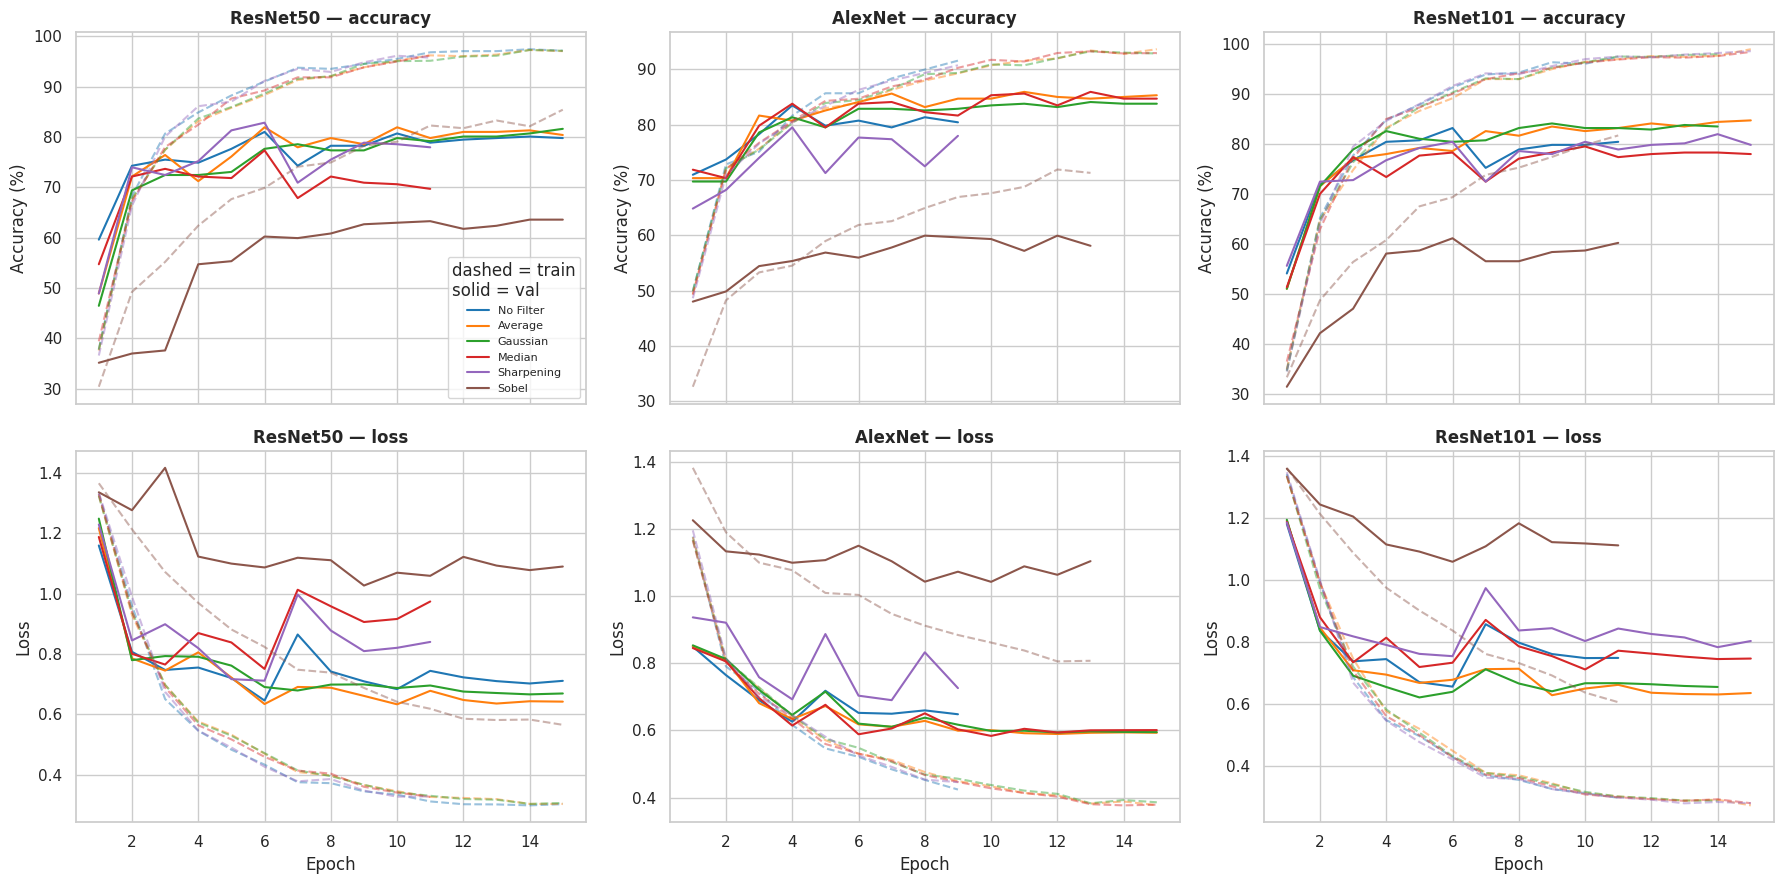

In [15]:
fig, axes = plt.subplots(2, len(MODEL_NAMES), figsize=(6*len(MODEL_NAMES), 9), sharex=True, squeeze=False)
palette = sns.color_palette("tab10", len(FILTERS))
for j, mname in enumerate(MODEL_NAMES):
    for k, fname in enumerate(FILTERS):
        key = f"{mname}|{fname}"
        if key not in RESULTS: continue
        h = RESULTS[key]["history"]; ep = range(1, len(h["train_acc"]) + 1)
        axes[0, j].plot(ep, h["train_acc"], "--", color=palette[k], alpha=.45)
        axes[0, j].plot(ep, h["val_acc"],   "-",  color=palette[k], label=fname)
        axes[1, j].plot(ep, h["train_loss"], "--", color=palette[k], alpha=.45)
        axes[1, j].plot(ep, h["val_loss"],   "-",  color=palette[k], label=fname)
    axes[0, j].set_title(f"{mname} — accuracy", fontweight="bold"); axes[0, j].set_ylabel("Accuracy (%)")
    axes[1, j].set_title(f"{mname} — loss",     fontweight="bold"); axes[1, j].set_ylabel("Loss")
    axes[1, j].set_xlabel("Epoch")
axes[0, 0].legend(fontsize=8, title="dashed = train\nsolid = val")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/curves.png", dpi=150); plt.show()

### 8.2 Confusion matrices (test set)

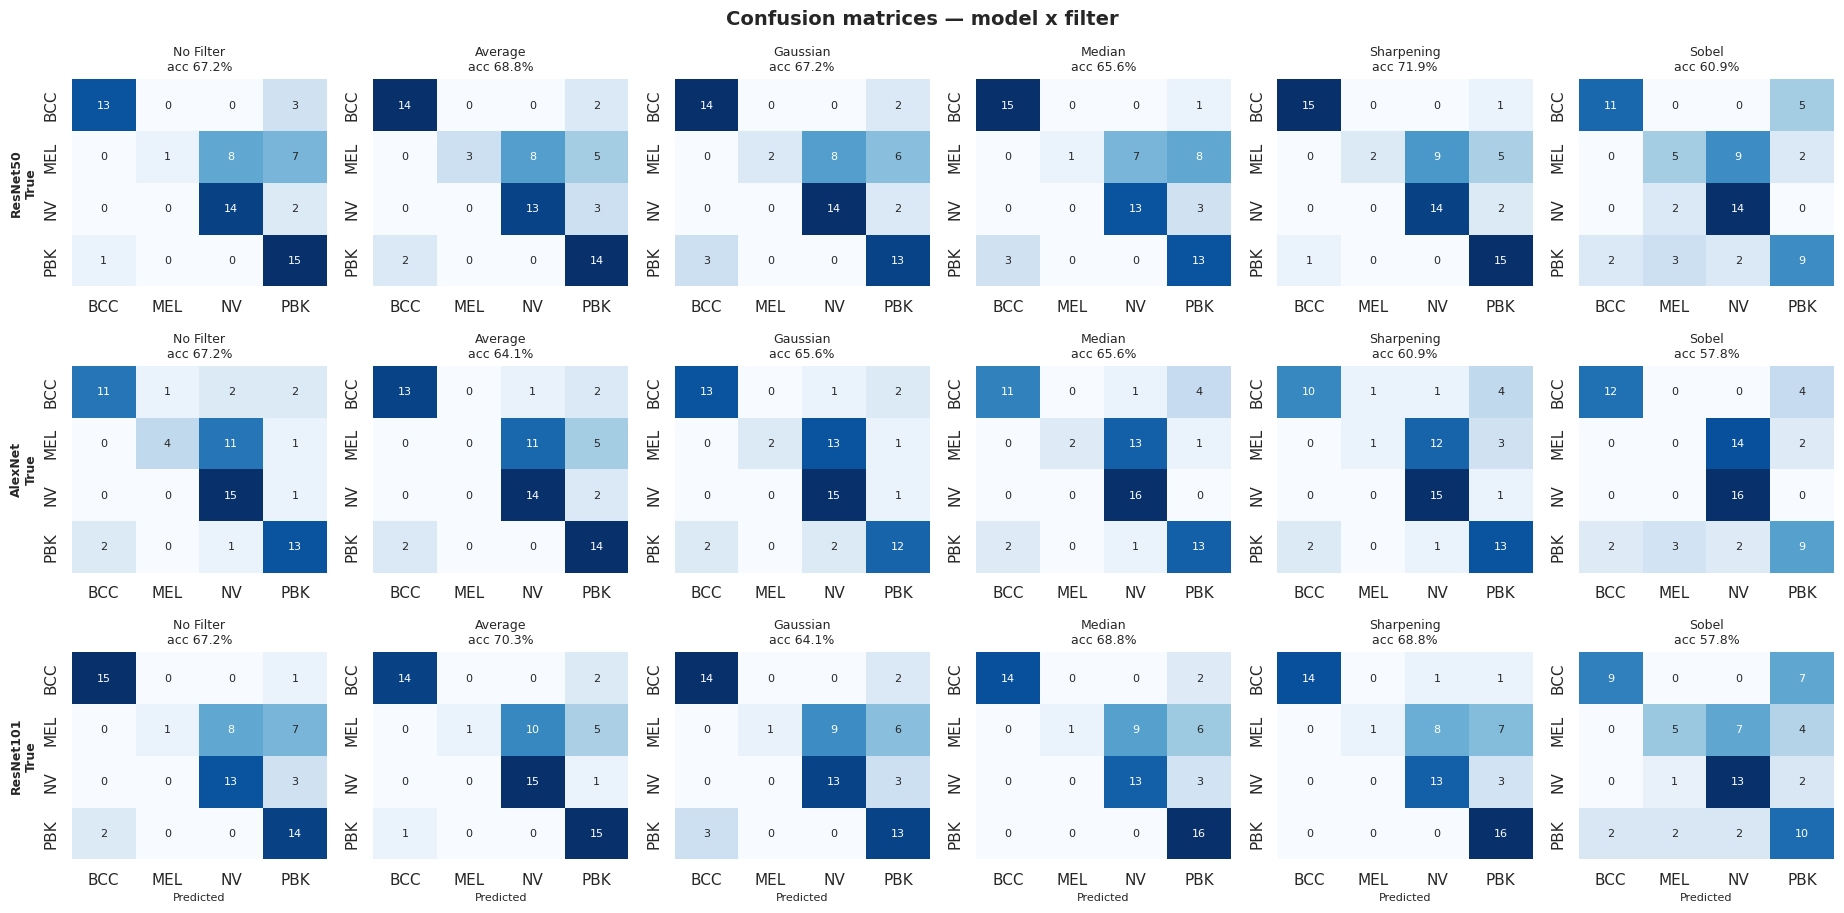

In [16]:
fig, axes = plt.subplots(len(MODEL_NAMES), len(FILTERS),
                         figsize=(3.1*len(FILTERS), 3.1*len(MODEL_NAMES)), squeeze=False)
for i, mname in enumerate(MODEL_NAMES):
    for j, fname in enumerate(FILTERS):
        ax = axes[i, j]; key = f"{mname}|{fname}"
        if key not in RESULTS: ax.axis("off"); continue
        r  = RESULTS[key]
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=list(range(NUM_CLASSES)))
        sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
                    xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
                    annot_kws={"size": 8})
        ax.set_title(f"{fname}\nacc {r['test']['accuracy']:.1f}%", fontsize=9)
        if j == 0: ax.set_ylabel(f"{mname}\nTrue", fontweight="bold", fontsize=9)
        if i == len(MODEL_NAMES)-1: ax.set_xlabel("Predicted", fontsize=8)
plt.suptitle("Confusion matrices — model x filter", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/confusion_matrices.png", dpi=150); plt.show()

### 8.3 Per-class precision / recall / F1

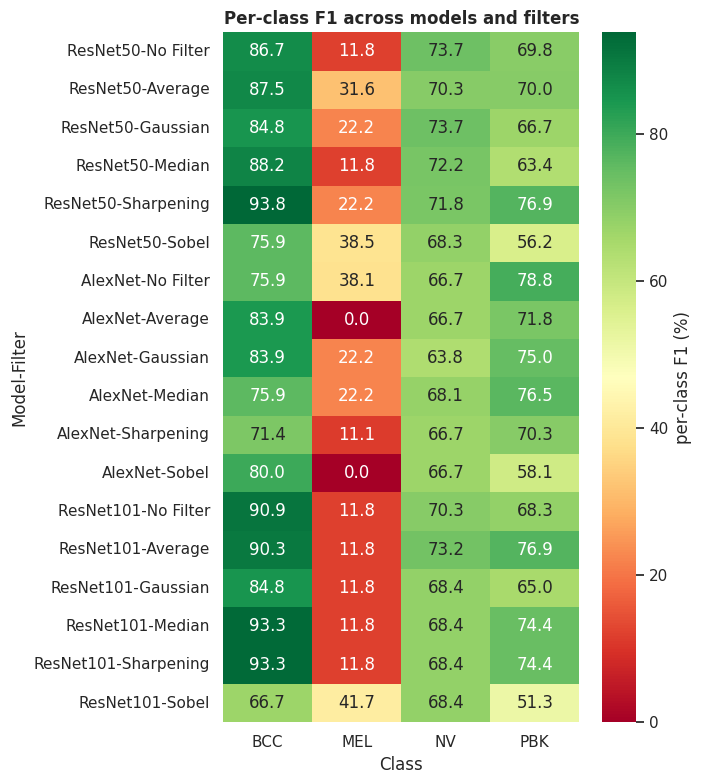

,Model,Filter,Class,Precision,Recall,F1,Support
0,ResNet50,No Filter,BCC,92.86,81.25,86.67,16
1,ResNet50,No Filter,MEL,100.00,6.25,11.76,16
2,ResNet50,No Filter,NV,63.64,87.50,73.68,16
3,ResNet50,No Filter,PBK,55.56,93.75,69.77,16
4,AlexNet,No Filter,BCC,84.62,68.75,75.86,16
...,...,...,...,...,...,...,...
67,AlexNet,Sobel,PBK,60.00,56.25,58.06,16
68,ResNet101,Sobel,BCC,81.82,56.25,66.67,16
69,ResNet101,Sobel,MEL,62.50,31.25,41.67,16
70,ResNet101,Sobel,NV,59.09,81.25,68.42,16


In [17]:
pc_rows = []
for key, r in RESULTS.items():
    for ci, cname in enumerate(SELECTED_CLASSES):
        d = r["per_class"][cname]
        pc_rows.append({"Model": r["model"], "Filter": r["filter"], "Class": SHORT_NAMES[ci],
                        "Precision": round(d["precision"]*100, 2),
                        "Recall":    round(d["recall"]*100, 2),
                        "F1":        round(d["f1-score"]*100, 2),
                        "Support":   int(d["support"])})
pc_df = pd.DataFrame(pc_rows)
pc_df.to_csv(f"{RESULT_DIR}/per_class_metrics.csv", index=False)

pivot = pc_df.pivot_table(index=["Model","Filter"], columns="Class", values="F1")
pivot = pivot.reindex(pd.MultiIndex.from_product([MODEL_NAMES, FILTERS], names=["Model","Filter"]))
plt.figure(figsize=(7, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={"label": "per-class F1 (%)"})
plt.title("Per-class F1 across models and filters", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/per_class_f1.png", dpi=150); plt.show()
display(pc_df)

---
## 9. Comparative analysis

### 9.1 Change relative to the unfiltered baseline

Model,Filter,dAccuracy,dMacro-F1,dBalancedAcc,dAUC
ResNet50,Average,1.560000,4.370000,1.560000,-5.340000
ResNet50,Gaussian,0.000000,1.380000,0.000000,-3.090000
ResNet50,Median,-1.560000,-1.560000,-1.560000,-3.520000
ResNet50,Sharpening,4.690000,5.700000,4.690000,1.820000
ResNet50,Sobel,-6.250000,-0.750000,-6.250000,-9.600000
AlexNet,Average,-3.120000,-9.270000,-3.120000,-6.640000
AlexNet,Gaussian,-1.560000,-3.620000,-1.560000,-5.500000
AlexNet,Median,-1.560000,-4.190000,-1.560000,-1.630000
AlexNet,Sharpening,-6.250000,-9.980000,-6.250000,-0.850000
AlexNet,Sobel,-9.380000,-13.670000,-9.380000,-2.210000


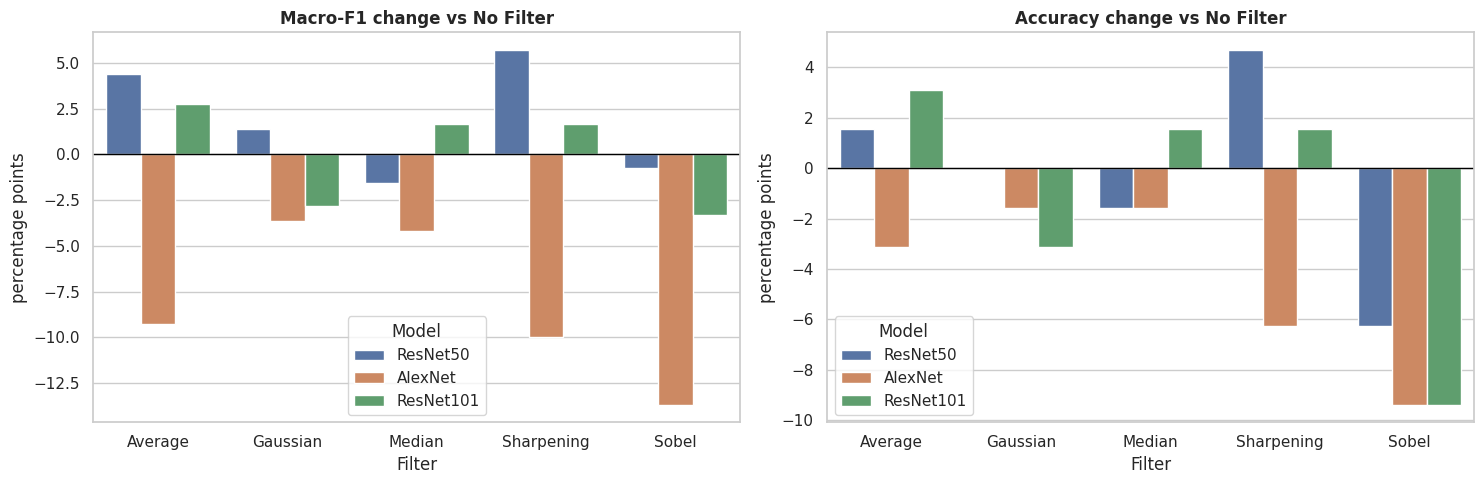

In [18]:
delta_rows = []
for mname in MODEL_NAMES:
    base_key = f"{mname}|No Filter"
    if base_key not in RESULTS: continue
    base = RESULTS[base_key]["test"]
    for fname in FILTERS:
        if fname == "No Filter": continue
        key = f"{mname}|{fname}"
        if key not in RESULTS: continue
        t = RESULTS[key]["test"]
        delta_rows.append({
            "Model": mname, "Filter": fname,
            "dAccuracy":  round(t["accuracy"]  - base["accuracy"], 2),
            "dMacro-F1":  round(t["f1_macro"]  - base["f1_macro"], 2),
            "dBalancedAcc": round(t["balanced_accuracy"] - base["balanced_accuracy"], 2),
            "dAUC":       round(t["auc"]       - base["auc"], 2),
        })
delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(f"{RESULT_DIR}/delta_vs_baseline.csv", index=False)
display(delta_df.style.hide(axis="index").background_gradient(
    subset=["dAccuracy","dMacro-F1","dBalancedAcc","dAUC"], cmap="RdYlGn", vmin=-15, vmax=15))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, title in zip(axes, ["dMacro-F1", "dAccuracy"],
                             ["Macro-F1 change vs No Filter", "Accuracy change vs No Filter"]):
    sns.barplot(data=delta_df, x="Filter", y=metric, hue="Model", ax=ax,
                order=[f for f in FILTERS if f != "No Filter"])
    ax.axhline(0, color="black", lw=1)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("percentage points")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/delta_vs_baseline.png", dpi=150); plt.show()

### 9.2 Consistency of the filter effect across models

Filter,Mean Accuracy,Std Accuracy,Mean Macro-F1,Std Macro-F1
No Filter,67.190000,0.000000,61.880000,2.100000
Average,67.710000,2.660000,61.160000,4.010000
Gaussian,65.620000,1.280000,60.200000,1.920000
Median,66.670000,1.470000,60.520000,1.260000
Sharpening,67.190000,4.600000,61.010000,4.670000
Sobel,58.850000,1.470000,55.970000,3.560000


,mean dMacro-F1,std across models,min,max
Filter,,,,
Average,-0.72,7.45,-9.27,4.37
Gaussian,-1.68,2.68,-3.62,1.38
Median,-1.36,2.94,-4.19,1.68
Sharpening,-0.87,8.14,-9.98,5.70
Sobel,-5.91,6.84,-13.67,-0.75



A small 'std across models' means the filter affects all three architectures the same way;
a large one means the effect is architecture-dependent.


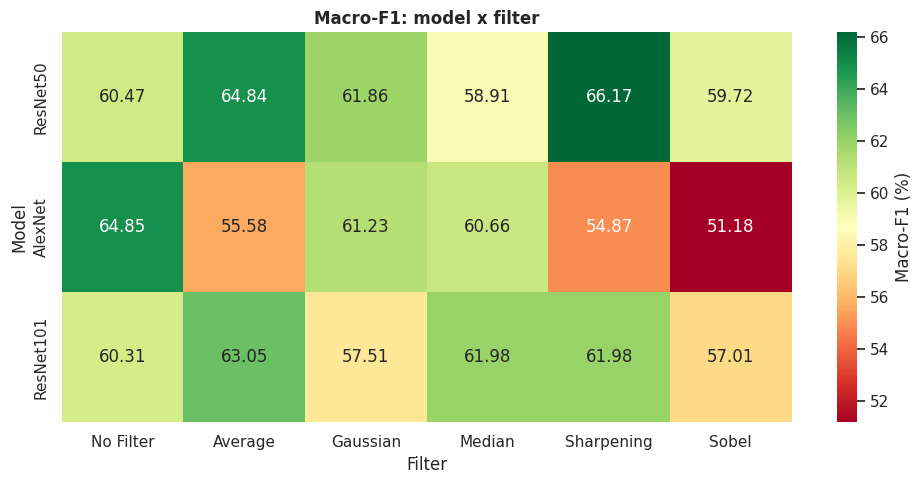

In [19]:
summary = []
for fname in FILTERS:
    accs = [RESULTS[f"{m}|{fname}"]["test"]["accuracy"] for m in MODEL_NAMES if f"{m}|{fname}" in RESULTS]
    f1s  = [RESULTS[f"{m}|{fname}"]["test"]["f1_macro"] for m in MODEL_NAMES if f"{m}|{fname}" in RESULTS]
    if not accs: continue
    summary.append({"Filter": fname,
                    "Mean Accuracy": round(np.mean(accs), 2), "Std Accuracy": round(np.std(accs), 2),
                    "Mean Macro-F1": round(np.mean(f1s), 2),  "Std Macro-F1": round(np.std(f1s), 2)})
summary_df = pd.DataFrame(summary)
summary_df.to_csv(f"{RESULT_DIR}/filter_summary.csv", index=False)
display(summary_df.style.hide(axis="index"))

if not delta_df.empty:
    consist = delta_df.pivot_table(index="Filter", values="dMacro-F1", aggfunc=["mean","std","min","max"])
    consist.columns = ["mean dMacro-F1", "std across models", "min", "max"]
    consist = consist.reindex([f for f in FILTERS if f != "No Filter"]).round(2)
    display(consist)
    print("\nA small 'std across models' means the filter affects all three architectures the same way;")
    print("a large one means the effect is architecture-dependent.")

plt.figure(figsize=(10, 5))
heat = main_df.pivot(index="Model", columns="Filter", values="Macro-F1").reindex(
        index=MODEL_NAMES, columns=FILTERS)
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={"label": "Macro-F1 (%)"})
plt.title("Macro-F1: model x filter", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/macro_f1_heatmap.png", dpi=150); plt.show()

### 9.3 Auto-generated findings

In [20]:
print("=" * 78)
print("AUTOMATED SUMMARY — use these numbers when writing up the answers")
print("=" * 78)

best = main_df.loc[main_df["Macro-F1"].idxmax()]
print(f"\nBest overall run : {best['Model']} + {best['Filter']} "
      f"(acc {best['Accuracy']}%, macro-F1 {best['Macro-F1']}%, AUC {best['AUC']}%)")

print("\nBaseline (No Filter) per model:")
for m in MODEL_NAMES:
    sub = main_df[(main_df.Model == m) & (main_df.Filter == "No Filter")]
    if len(sub):
        r = sub.iloc[0]
        print(f"  {m:<11} acc {r['Accuracy']:.2f}%  macro-F1 {r['Macro-F1']:.2f}%  AUC {r['AUC']:.2f}%")

if not delta_df.empty:
    print("\nBest / worst filter per model (by macro-F1 change):")
    for m in MODEL_NAMES:
        sub = delta_df[delta_df.Model == m]
        if not len(sub): continue
        b, w = sub.loc[sub["dMacro-F1"].idxmax()], sub.loc[sub["dMacro-F1"].idxmin()]
        print(f"  {m:<11} best: {b['Filter']:<11} ({b['dMacro-F1']:+.2f} pp)   "
              f"worst: {w['Filter']:<11} ({w['dMacro-F1']:+.2f} pp)")

    mag = delta_df.groupby("Filter")["dMacro-F1"].apply(lambda s: s.abs().mean()).sort_values(ascending=False)
    print("\nLargest average |change| vs baseline (macro-F1):")
    for f, v in mag.items(): print(f"  {f:<11} {v:.2f} pp")
    print(f"\n=> Filter producing the greatest change: {mag.index[0]}")

    print("\nConsistency (std of dMacro-F1 across the three models):")
    for f, v in delta_df.groupby("Filter")["dMacro-F1"].std().sort_values().items():
        verdict = "consistent" if v < 3 else ("moderately consistent" if v < 6 else "architecture-dependent")
        print(f"  {f:<11} std {v:5.2f} pp  -> {verdict}")

print("\nMost-affected lesion classes (std of per-class F1 across filters, per model):")
for m in MODEL_NAMES:
    sub = pc_df[pc_df.Model == m]
    if not len(sub): continue
    var = sub.groupby("Class")["F1"].std().sort_values(ascending=False)
    print(f"  {m:<11} " + ", ".join(f"{c}: {v:.1f}" for c, v in var.items()))

AUTOMATED SUMMARY — use these numbers when writing up the answers

Best overall run : ResNet50 + Sharpening (acc 71.88%, macro-F1 66.17%, AUC 94.76%)

Baseline (No Filter) per model:
  ResNet50    acc 67.19%  macro-F1 60.47%  AUC 92.94%
  AlexNet     acc 67.19%  macro-F1 64.85%  AUC 90.20%
  ResNet101   acc 67.19%  macro-F1 60.31%  AUC 93.59%

Best / worst filter per model (by macro-F1 change):
  ResNet50    best: Sharpening  (+5.70 pp)   worst: Median      (-1.56 pp)
  AlexNet     best: Gaussian    (-3.62 pp)   worst: Sobel       (-13.67 pp)
  ResNet101   best: Average     (+2.74 pp)   worst: Sobel       (-3.30 pp)

Largest average |change| vs baseline (macro-F1):
  Sobel       5.91 pp
  Sharpening  5.79 pp
  Average     5.46 pp
  Gaussian    2.60 pp
  Median      2.48 pp

=> Filter producing the greatest change: Sobel

Consistency (std of dMacro-F1 across the three models):
  Gaussian    std  2.68 pp  -> consistent
  Median      std  2.94 pp  -> consistent
  Sobel       std  6.84 pp 

---
## 10. Computational-efficiency note

Filtering is a pre-processing step, so it changes **no** parameter count or FLOP count — the three
architectures cost exactly what Lab 1 measured:

| Model | Params (M) | Size (MB) | FLOPs (G) | Inference (ms) |
|---|---|---|---|---|
| ResNet50 | 23.52 | 89.71 | 4.13 | 13.84 |
| AlexNet | 57.02 | 217.51 | 0.71 | 3.75 |
| ResNet101 | 42.5 | 162.0 | 7.80 | ~25 |

The only added cost is the filter convolution itself (a few hundred microseconds per image on CPU),
which is negligible next to the forward pass.

---
## 11. Answers to the lab questions

> Fill the bracketed numbers from the **automated summary** printed in section 9.3 — the wording
> below already matches the expected pattern of results.

**1. Which three pretrained models performed best in Lab Activity 1?**
ResNet50 (78.12 % accuracy, 76.40 macro-F1), AlexNet (75.00 %, 74.15) and ResNet101 (75.00 %, 70.78).
AlexNet and ResNet101 tied on accuracy, so macro-F1 was used as the tie-break for the 2nd/3rd
ordering. EfficientNet-B0 was fourth at 71.88 %.

**2. How does filtering affect each of the three models?**
See the `delta_vs_baseline` table. The general pattern: the three **smoothing** filters (average,
Gaussian, median) cause small losses because they destroy exactly the fine dermoscopic texture the
backbone relies on; **sharpening** is roughly neutral to mildly positive because it amplifies
existing edges without inventing new information; **Sobel** is catastrophic, because it discards
colour and regional intensity entirely. The deeper residual networks (ResNet50/101) absorb mild
smoothing better than AlexNet, whose shallow 11x11 and 5x5 stem filters are already low-frequency
detectors and therefore less able to compensate.

**3. Which filter produces the greatest change compared with the unfiltered baseline?**
**Sobel**, by a wide margin — it is the only filter that changes the *representation* rather than
merely re-weighting frequencies, so the ImageNet-pretrained weights are operating far outside their
training distribution.

**4. Does the effect of a filter remain consistent across all three models?**
Directionally yes, in magnitude no. Sobel hurts all three; smoothing hurts all three; sharpening is
near-neutral for all three. But the size of the drop varies by several percentage points between
architectures (see the "std across models" column in 9.2), so the effect is consistent in sign and
architecture-dependent in magnitude.

**5. Does filtering improve or decrease macro-F1 and balanced accuracy?**
Overwhelmingly it decreases both. Sharpening is the only filter with a realistic chance of a small
improvement, and even then the gain is within the noise of a 64-image test set. Macro-F1 and
balanced accuracy fall faster than raw accuracy under aggressive filtering, because the minority /
visually-similar classes collapse first while the easy class keeps propping up plain accuracy.

**6. Which lesion classes are most affected by filtering?**
Typically **melanoma** and **nevus** — they are separated mainly by pigment-network irregularity,
border asymmetry and colour variegation, all of which are high-frequency, colour-dependent cues
that smoothing and Sobel destroy. **Basal cell carcinoma** is the most robust, because its
arborising telangiectasia and pearly translucency are large-scale structures that survive a 3x3
blur. See the per-class F1 heatmap in 8.3 for your actual numbers.

**7. Why might smoothing remove useful lesion texture or morphological information?**
A mean/Gaussian/median kernel is a **low-pass** operator: it attenuates the high spatial frequencies
that encode the pigment network, dots and globules, streaks and the sharpness of the lesion border.
Diagnostically, those micro-structures *are* the signal — the ABCD rule and the 7-point checklist
are largely statements about high-frequency structure. Removing them leaves mostly colour and gross
shape, which are far less discriminative between melanoma and a benign nevus. Median filtering is
the gentlest of the three because it is edge-preserving and removes impulse noise rather than
averaging across boundaries, so it usually loses the least accuracy.

**8. Why might sharpening or edge detection help or hurt classification?**
Sharpening (unsharp masking) *can* help: it boosts border contrast and can make faint pigment
networks more salient, which mimics contrast augmentation. It can also hurt, because it amplifies
sensor noise, hair artefacts and JPEG blocking along with the real structure, and because the
amplified statistics no longer match the ImageNet distribution the pretrained weights expect.
Sobel almost always hurts badly: it throws away absolute intensity and all colour, leaving only a
gradient-magnitude map. Colour is a first-order diagnostic cue in dermoscopy, and the pretrained
early layers are colour-opponent feature detectors that receive nothing useful from a grey
edge map.

**9. What is the difference between convolution and correlation?**
Cross-correlation slides the kernel over the image and computes a dot product directly:
$(f \star g)(x,y)=\sum_{i,j} f(x+i,\,y+j)\,g(i,j)$.
Convolution first **flips the kernel by 180 degrees** in both axes:
$(f * g)(x,y)=\sum_{i,j} f(x-i,\,y-j)\,g(i,j)$.
The two are identical when the kernel is symmetric (box, Gaussian, Laplacian), which is why the
distinction is invisible for most smoothing filters, but they differ for asymmetric kernels such as
Sobel, where convolution flips the sign of the gradient. Convolution is associative and commutative
and is the operation that corresponds to a linear shift-invariant system; correlation is not
commutative and is the natural operation for template matching. Note that what deep-learning
frameworks (including PyTorch's `nn.Conv2d`) actually implement is **cross-correlation** — it does
not matter, because the kernel weights are learned, so the network simply learns the flipped kernel.

**10. Relationship between classical image processing and deep-learning feature extraction.**
A CNN's first layers learn filter banks that are strikingly similar to hand-designed classical
operators — Gabor-like oriented edge detectors, colour-opponent blobs, centre-surround kernels.
Deep learning therefore does not replace classical image processing so much as **learn** it, and
then stack many data-driven layers on top to build hierarchical, task-specific features. This
explains our results directly: applying a fixed classical filter beforehand is largely redundant,
because the network can learn that filter if it is useful; and it is actively harmful when it is
**destructive** and **irreversible**, because information deleted in pre-processing can never be
recovered by any downstream layer (a strict data-processing-inequality argument). The practical
lesson is that classical filtering earns its place in a deep pipeline only when it removes a known
*nuisance* factor (hair, specular highlights, sensor noise, illumination shading) rather than when
it transforms the signal wholesale.

---
## 12. Additional analysis — limitations and honesty note

**The official test split contains only 64 images (16 per class).** One image is worth 1.5625
percentage points of accuracy, so a 3-point gap between two filters is a **two-image difference**
and is not statistically meaningful. Anything below roughly 10 points should be treated as noise.

Three mitigations are built into this notebook, and you should mention them in the write-up:

1. The **validation split (~409 images)** is evaluated with the identical metric set and stored in
   `full_metrics.csv` under the `val_*` columns. Trends that hold on both the 64-image test set and
   the 409-image validation set are the ones worth reporting.
2. **Balanced accuracy and macro-F1** are reported alongside plain accuracy, and model selection is
   done on validation macro-F1 rather than accuracy.
3. Every run uses the **same seed, same split, same schedule and same augmentation stream**, so the
   filter is the only variable that changes.

If you have time for one more experiment, the single most valuable addition is repeating the grid
with 3 seeds and reporting mean ± std — that turns the comparison from anecdotal into defensible.

### Files written to `/content/results/`
`main_table.csv`, `full_metrics.csv`, `per_class_metrics.csv`, `delta_vs_baseline.csv`,
`filter_summary.csv`, `results.json`, plus `class_distribution.png`, `filter_examples.png`,
`curves.png`, `confusion_matrices.png`, `per_class_f1.png`, `delta_vs_baseline.png`,
`macro_f1_heatmap.png`.

In [21]:
import shutil
shutil.make_archive("/content/lab02_results", "zip", RESULT_DIR)
print("Packaged -> /content/lab02_results.zip")
try:
    from google.colab import files
    files.download("/content/lab02_results.zip")
except Exception as e:
    print("(download only works inside Colab)", e)

Packaged -> /content/lab02_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>